# Pipeline de Engenharia de Métricas para Classificação Multiclasse — Covtype Dataset

Este notebook implementa um pipeline desacoplado e modular para a extração de diagnósticos de performance em modelos de classificação, utilizando como validação o conjunto de dados florestais *Covertype* (Covtype).

### Aspectos Técnicos e Competências Implementadas:
*   **Paradigmas de Desenvolvimento:** Migração de scripts imperativos lineares para Programação Orientada a Objetos (POO), garantindo o encapsulamento da lógica de validação e a reusabilidade do código.
*   **Tipagem Estruturada:** Uso de *Type Hints* nativos do Python para assegurar a consistência das matrizes e arrays do NumPy durante a execução do pipeline.
*   **Amostragem Estratificada de Alto Volume:** Engenharia de amostragem utilizando `resample` para reduzir o dataset massivo de 581.012 linhas para 20.000 amostras, preservando a distribuição de classes original para viabilidade de hardware.
*   **Tratamento de Escala Multiclasse:** Aplicação da estratégia matemática *One-vs-Rest* (OvR) através da binarização de labels para o cálculo preciso de taxas de falsos e verdadeiros positivos (Curva ROC/AUC) em um cenário complexo de 7 classes.


**Instituição de Origem:** Desafio DIO (Digital Innovation One).

## Etapa 1: Definição da Arquitetura de Avaliação (Engenharia de Código)

Nesta etapa, construímos a classe `PerformanceEvaluator`. Encapsulamos a lógica de cálculo do relatório de classificação, da matriz de confusão e das curvas ROC em uma estrutura modular baseada em objetos. A classe gerencia o mapeamento de 7 classes e utiliza o dicionário de cores moderno do Matplotlib para garantir a compatibilidade e a longevidade do código.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from typing import List, Optional

class PerformanceEvaluator:
    """
    Classe responsável por centralizar a avaliação de modelos de classificação
    multiclasse, gerando relatórios textuais e diagnósticos visuais.
    """
    def __init__(self, y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray, class_names: Optional[List[str]] = None):
        self.y_true = y_true
        self.y_pred = y_pred
        self.y_prob = y_prob
        self.n_classes = len(np.unique(y_true))
        self.class_names = class_names or [f"Classe {i}" for i in range(self.n_classes)]
        
    def log_classification_report(self) -> None:
        """Exibe o relatório principal com Precision, Recall e F1-Score."""
        print("=== Relatório de Classificação ===")
        print(classification_report(self.y_true, self.y_pred, target_names=self.class_names))
        
    def plot_confusion_matrix(self, figsize: tuple = (10, 8), cmap: str = "Blues") -> None:
        """Gera e exibe a matriz de confusão normalizada por linha para equilibrar o gradiente visual."""
        cm = confusion_matrix(self.y_true, self.y_pred, normalize='true')
        plt.figure(figsize=figsize)
        sns.heatmap(cm, annot=True, fmt=".2f", cmap=cmap, 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title("Matriz de Confusão Normalizada — 7 Classes Florestais", fontsize=12, pad=15)
        plt.ylabel("Label Verdadeiro")
        plt.xlabel("Label Previsto")
        plt.tight_layout()
        plt.show()
        
    def plot_roc_curves(self, figsize: tuple = (10, 8)) -> None:
        """Calcula e plota as curvas ROC individuais utilizando a estratégia One-vs-Rest."""
        y_true_bin = label_binarize(self.y_true, classes=list(range(self.n_classes)))
        
        plt.figure(figsize=figsize)
        colors = plt.colormaps["tab10"](np.linspace(0, 1, self.n_classes))
        
        for i, color in enumerate(colors):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], self.y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=color, lw=2, 
                     label=f"Curva ROC — {self.class_names[i]} (AUC = {roc_auc:.2f})")
            
        plt.plot([0, 1], [0, 1], color="black", lw=1.5, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("Taxa de Falsos Positivos (FPR)")
        plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
        plt.title("Curva ROC Multiclasse (One-vs-Rest)", fontsize=12, pad=15)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Etapa 2: Carregamento, Amostragem e Particionamento dos Dados

Aqui consumimos o *Covtype Dataset* obtido via Scikit-Learn. Para contornar a volatilidade de memória e processamento das mais de 581 mil linhas originais, aplico uma redução estratificada para 20.000 amostras. Também realizo o alinhamento de índices (subtraindo 1) para adequar o mapeamento das 7 classes florestais reais ao padrão numérico do Python (0 a 6). A partição final separa os dados em 80% para treino e 20% para teste.

In [16]:
print("Carregando o Covtype Dataset...")
# Carregamento da base total
covtype = fetch_covtype()
X_total = covtype.data
y_total = covtype.target

# Amostragem Estratificada para viabilidade de hardware
X_amostra, y_amostra = resample(
    X_total, y_total, 
    n_samples=20000, 
    replace=False, 
    stratify=y_total, 
    random_state=42
)

# Rótulos textuais oficiais do repositório UCI para as 7 classes florestais
class_labels = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", 
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Divisão estratificada entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_amostra, y_amostra, test_size=0.2, random_state=42, stratify=y_amostra
)

# Alinhamento de índice para o padrão zero-based do Python (1-7 para 0-6)
y_train = y_train - 1
y_test = y_test - 1

print(f"\nDataset carregado e amostrado com sucesso.")
print(f"Amostras de treino: {X_train.shape[0]} | Amostras de teste: {X_test.shape[0]}")
print(f"Número de features: {X_train.shape[1]} | Número de classes: {len(class_labels)}")

Carregando o Covtype Dataset...

Dataset carregado e amostrado com sucesso.
Amostras de treino: 16000 | Amostras de teste: 4000
Número de features: 54 | Número de classes: 7


## Etapa 3: Treinamento do Modelo e Extração de Predições

Nesta fase, instanciamos o classificador `RandomForestClassifier` com 100 árvores de decisão. O modelo mapeará as características geográficas e cartográficas para aprender a distinguir os padrões florestais. Após o ajuste, isolamos as previsões discretas das probabilidades (`predict_proba`), fornecendo a variabilidade estatística necessária para testar o comportamento real das nossas curvas de diagnóstico.

In [17]:
# Inicialização e ajuste do classificador Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Geração das saídas para avaliação
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

## Etapa 4: Execução dos Diagnósticos de Desempenho

Por fim, instanciamos a nossa classe avaliadora injetando os dados reais de teste e as predições geradas. Executamos os métodos de exibição para avaliar o desempenho real do modelo. 

=== Relatório de Classificação ===
                   precision    recall  f1-score   support

       Spruce/Fir       0.85      0.79      0.82      1458
   Lodgepole Pine       0.83      0.90      0.87      1951
   Ponderosa Pine       0.77      0.92      0.84       246
Cottonwood/Willow       0.70      0.37      0.48        19
            Aspen       0.90      0.28      0.42        65
      Douglas-fir       0.85      0.56      0.67       120
        Krummholz       0.89      0.74      0.81       141

         accuracy                           0.83      4000
        macro avg       0.83      0.65      0.70      4000
     weighted avg       0.84      0.83      0.83      4000



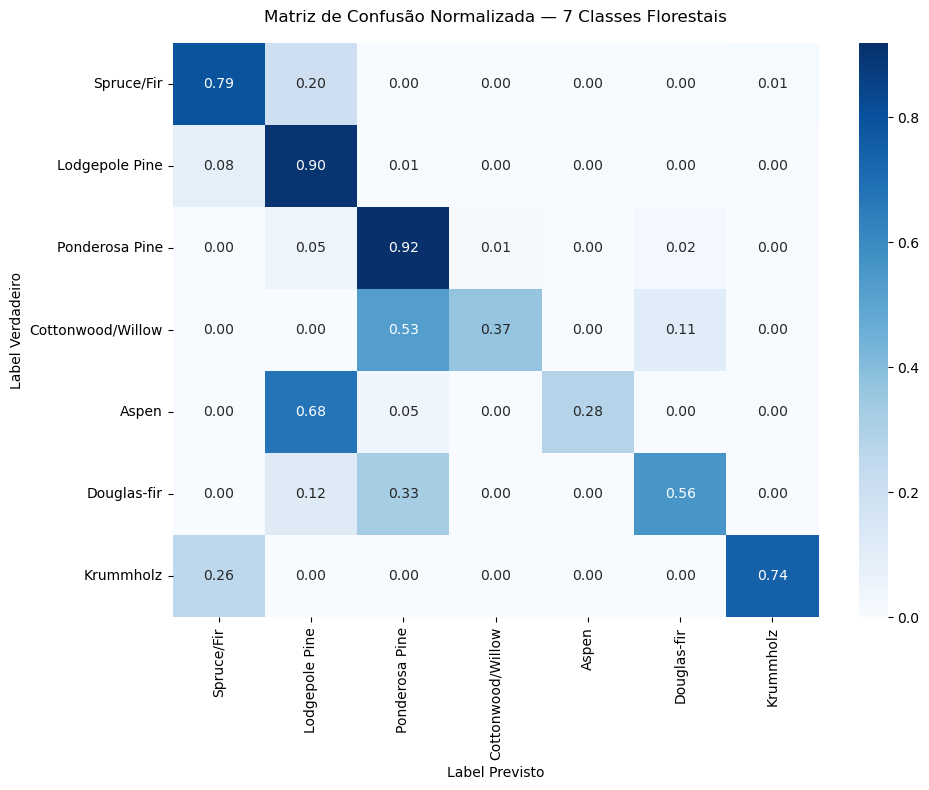

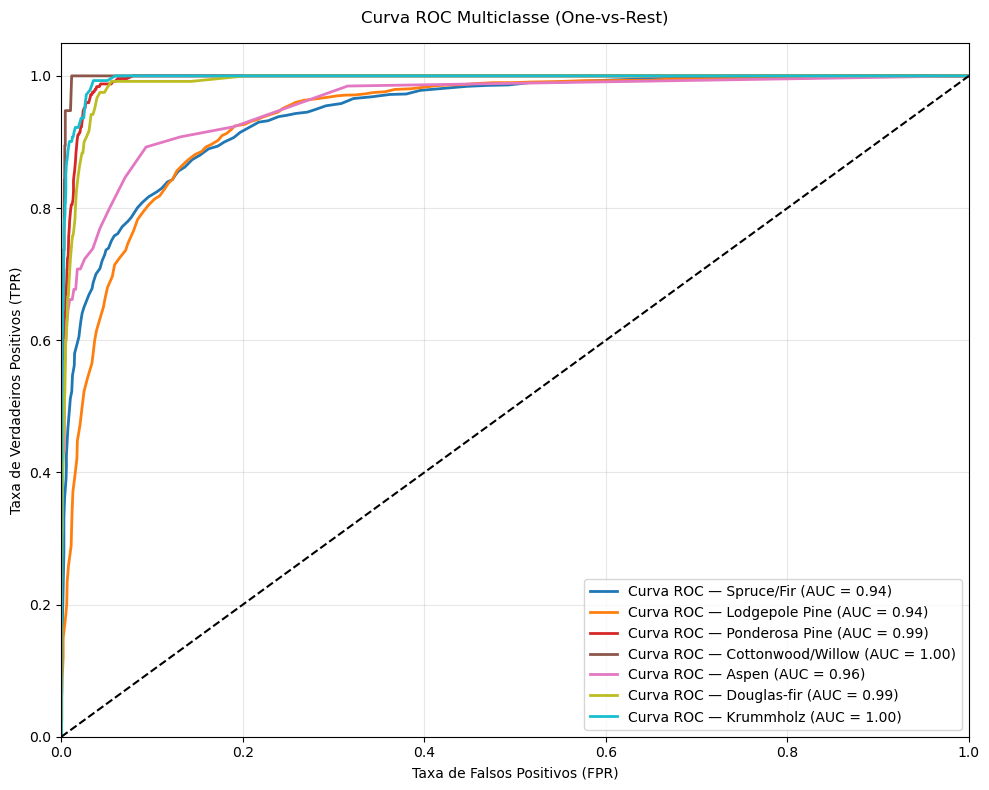

In [18]:
# Instanciação da classe com as saídas do Covtype
evaluator = PerformanceEvaluator(y_true=y_test, y_pred=y_pred, y_prob=y_prob, class_names=class_labels)

# Execução das ferramentas de diagnóstico
evaluator.log_classification_report()
evaluator.plot_confusion_matrix()
evaluator.plot_roc_curves()